In [3]:
!pip install spotipy

import requests
import base64
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyOAuth
from google.colab import files

# Spotify API credentials
CLIENT_ID = 'b95279648f384294a58551efb51c546f'
CLIENT_SECRET = '7e731490553d4a2784dccc3a110739d5'

# Base64 encode the client ID and client secret
client_credentials = f"{CLIENT_ID}:{CLIENT_SECRET}"
client_credentials_base64 = base64.b64encode(client_credentials.encode())

# Get the access token from Spotify API
token_url = 'https://accounts.spotify.com/api/token'
headers = {
    'Authorization': f'Basic {client_credentials_base64.decode()}'
}
data = {
    'grant_type': 'client_credentials'
}
response = requests.post(token_url, data=data, headers=headers)

if response.status_code == 200:
    access_token = response.json()['access_token']
    print("Access token obtained successfully.")
else:
    print("Error obtaining access token.")
    exit()

# get playlist data from Spotify
def get_trending_playlist_data(playlist_id, access_token):
    sp = spotipy.Spotify(auth=access_token)
    playlist_tracks = sp.playlist_tracks(playlist_id, fields='items(track(id, name, artists, album(id, name)))')

    music_data = []
    for track_info in playlist_tracks['items']:
        track = track_info['track']
        track_name = track['name']
        artists = ', '.join([artist['name'] for artist in track['artists']])
        album_name = track['album']['name']
        album_id = track['album']['id']
        track_id = track['id']

        # Get audio features for the track
        audio_features = sp.audio_features(track_id)[0] if track_id != 'Not available' else None

        # Get release date of the album
        try:
            album_info = sp.album(album_id) if album_id != 'Not available' else None
            release_date = album_info['release_date'] if album_info else None
        except:
            release_date = None

        # Get popularity of the track
        try:
            track_info = sp.track(track_id) if track_id != 'Not available' else None
            popularity = track_info['popularity'] if track_info else None
        except:
            popularity = None

        # Append track data to the list
        track_data = {
            'Track Name': track_name,
            'Artists': artists,
            'Album Name': album_name,
            'Album ID': album_id,
            'Track ID': track_id,
            'Popularity': popularity,
            'Release Date': release_date,
            'Duration (ms)': audio_features['duration_ms'] if audio_features else None,
            'Explicit': track_info.get('explicit', None),
            'External URLs': track_info.get('external_urls', {}).get('spotify', None),
            'Danceability': audio_features['danceability'] if audio_features else None,
            'Energy': audio_features['energy'] if audio_features else None,
            'Key': audio_features['key'] if audio_features else None,
            'Loudness': audio_features['loudness'] if audio_features else None,
            'Mode': audio_features['mode'] if audio_features else None,
            'Speechiness': audio_features['speechiness'] if audio_features else None,
            'Acousticness': audio_features['acousticness'] if audio_features else None,
            'Instrumentalness': audio_features['instrumentalness'] if audio_features else None,
            'Liveness': audio_features['liveness'] if audio_features else None,
            'Valence': audio_features['valence'] if audio_features else None,
            'Tempo': audio_features['tempo'] if audio_features else None,
        }

        music_data.append(track_data)

    # Create a DataFrame from the list of dictionaries
    df = pd.DataFrame(music_data)
    return df

# Spotify playlist ID
playlist_id = '7mpyCd3FQRgNx6LLAqhU3P'

# Get the playlist data and create a DataFrame
music_df = get_trending_playlist_data(playlist_id, access_token)

# Save the DataFrame as a CSV file
file_name = 'RazorMan_playlist_data.csv'
music_df.to_csv(file_name, index=False)

# Download the CSV file to the local system
files.download(file_name)

print(f"DataFrame saved and downloaded as {file_name}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.3/261.3 kB 10.7 MB/s eta 0:00:00
Access token obtained successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DataFrame saved and downloaded as RazorMan_playlist_data.csv


<ipython-input-4-e507d1f41655>:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


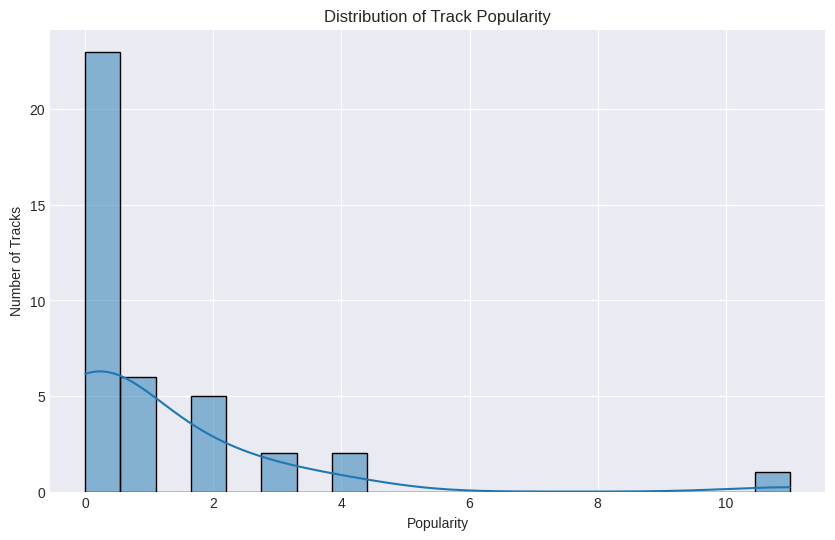

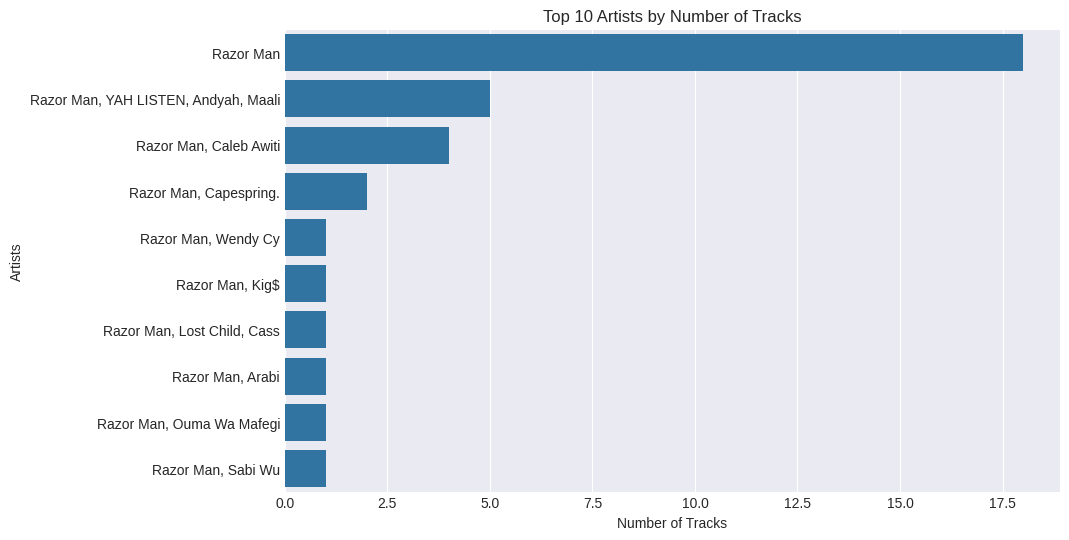

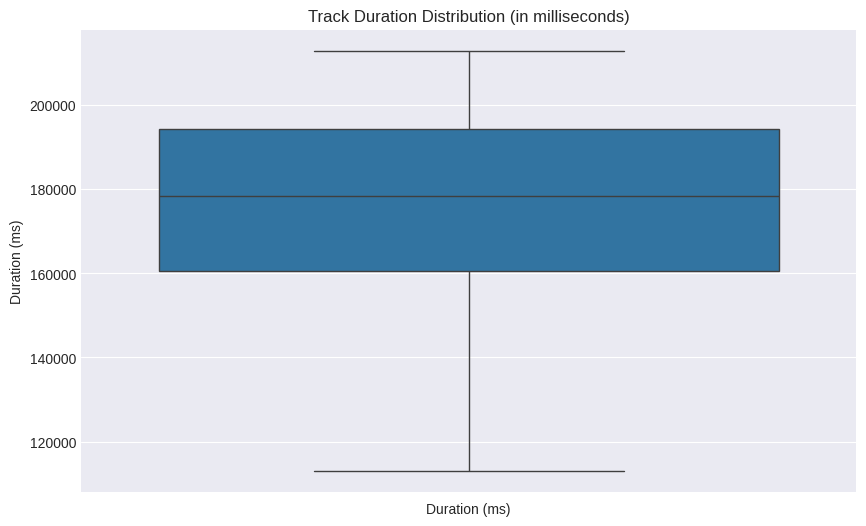

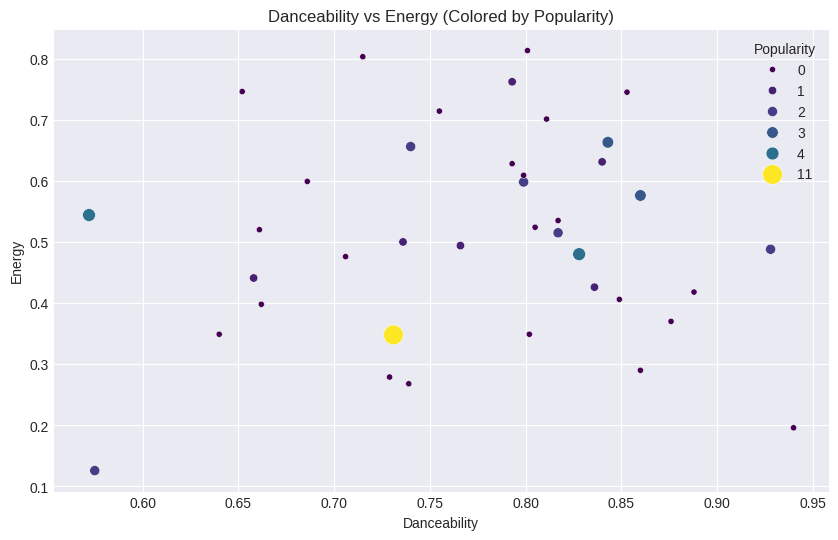

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting environment
plt.style.use('seaborn-darkgrid')

# 1. Popularity Distribution
plt.figure(figsize=(10, 6))
sns.histplot(music_df['Popularity'], kde=True, bins=20)
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity')
plt.ylabel('Number of Tracks')
plt.show()

# 2. Top Artists (by number of tracks)
top_artists = music_df['Artists'].value_counts().head(10)  # Top 10 artists
plt.figure(figsize=(10, 6))
sns.barplot(y=top_artists.index, x=top_artists.values)
plt.title('Top 10 Artists by Number of Tracks')
plt.xlabel('Number of Tracks')
plt.ylabel('Artists')
plt.show()

# 3. Track Duration Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(music_df['Duration (ms)'])
plt.title('Track Duration Distribution (in milliseconds)')
plt.xlabel('Duration (ms)')
plt.show()

# 4. Danceability vs Energy
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Danceability', y='Energy', data=music_df, hue='Popularity', size='Popularity', sizes=(20, 200), palette='viridis')
plt.title('Danceability vs Energy (Colored by Popularity)')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.show()


<ipython-input-6-05ed614a2dc0>:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')
<ipython-input-6-05ed614a2dc0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Popularity', y='Album Name', data=album_performance, palette='Blues_d')


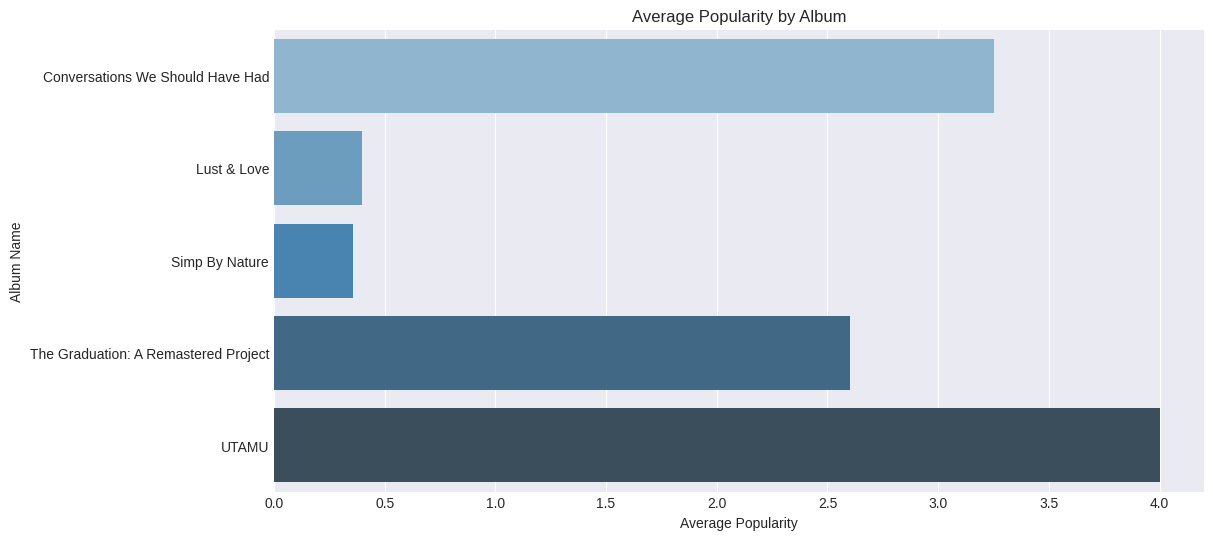

<ipython-input-6-05ed614a2dc0>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Danceability', y='Album Name', data=album_performance, palette='Greens_d')


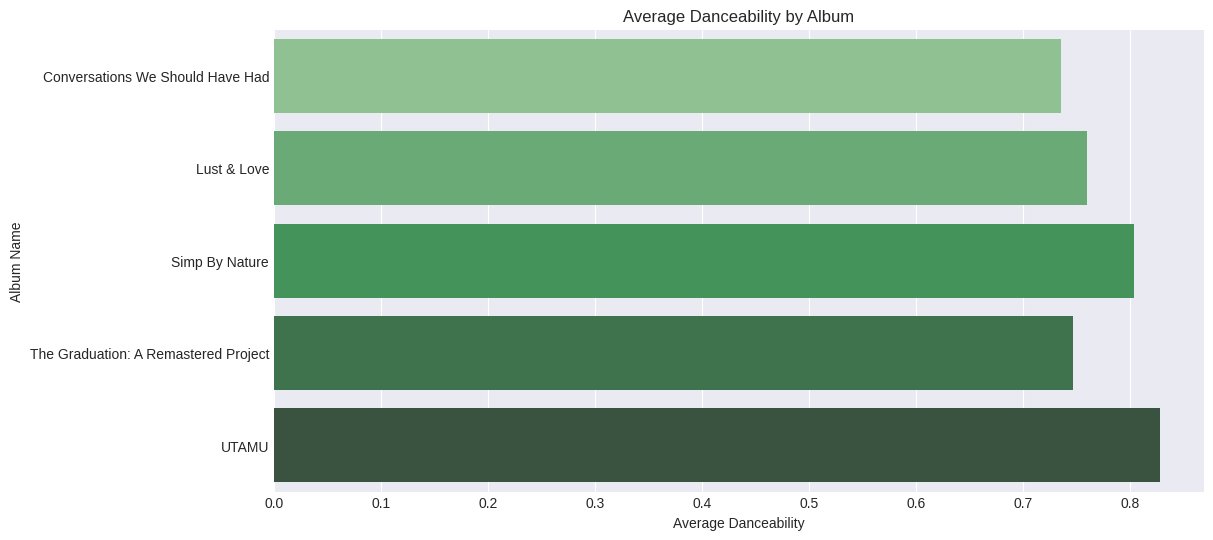

<ipython-input-6-05ed614a2dc0>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Energy', y='Album Name', data=album_performance, palette='Reds_d')


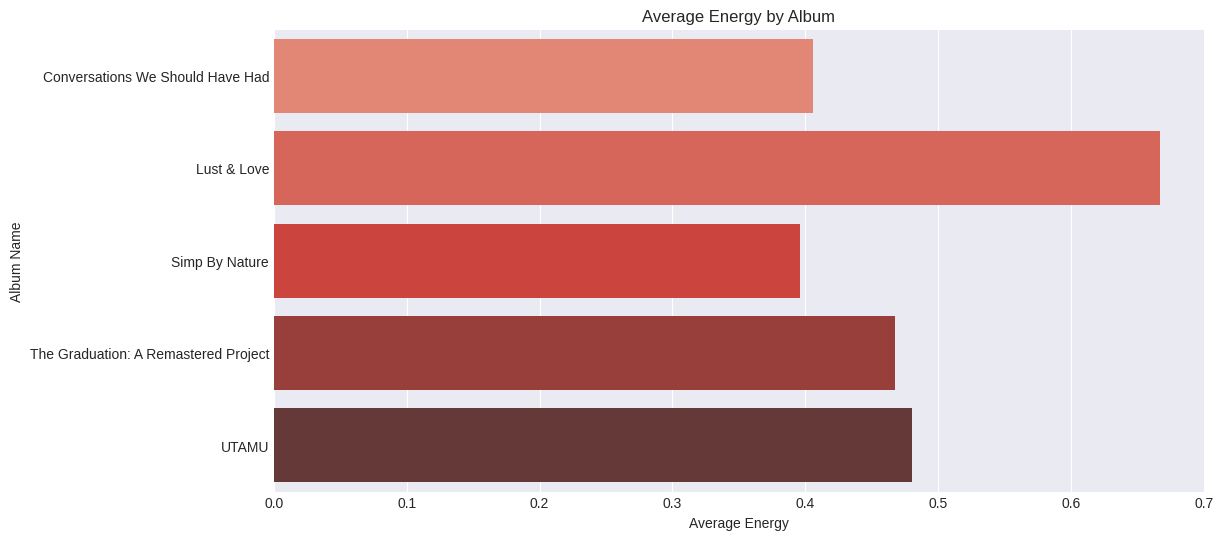

<ipython-input-6-05ed614a2dc0>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loudness', y='Album Name', data=album_performance, palette='Purples_d')


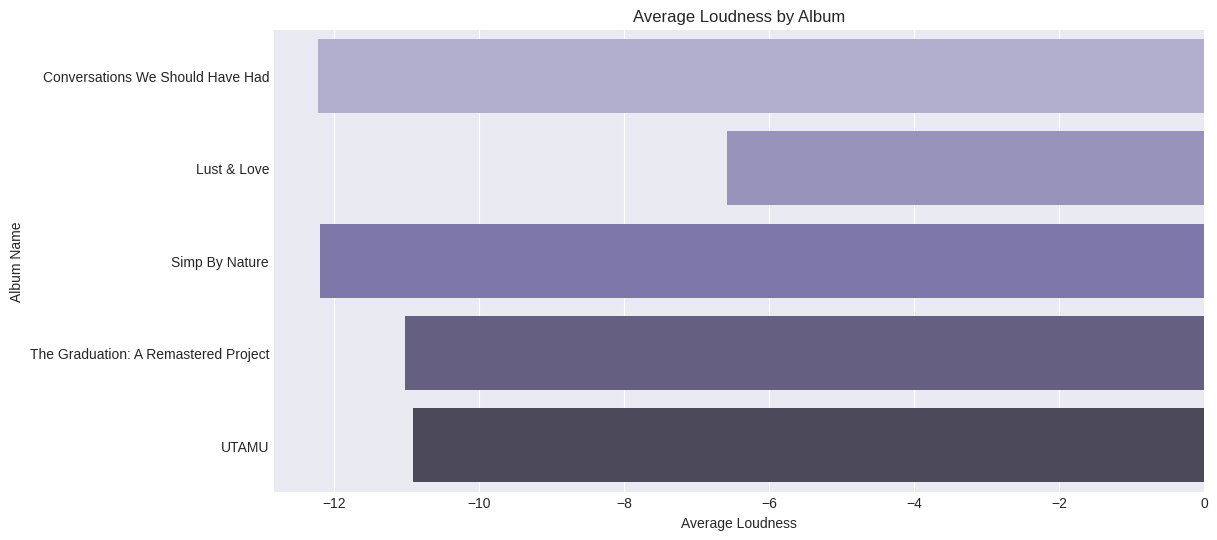

In [6]:
# Select only numeric columns for aggregation
numeric_columns = ['Popularity', 'Danceability', 'Energy', 'Loudness', 'Tempo', 'Valence', 'Speechiness',
                   'Acousticness', 'Instrumentalness', 'Liveness', 'Duration (ms)']

# Group by 'Album Name' and compute the mean for numeric columns
album_performance = music_df.groupby('Album Name')[numeric_columns].mean().reset_index()

# Plotting setup
plt.style.use('seaborn-darkgrid')

# 1. Popularity by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Popularity', y='Album Name', data=album_performance, palette='Blues_d')
plt.title('Average Popularity by Album')
plt.xlabel('Average Popularity')
plt.ylabel('Album Name')
plt.show()

# 2. Danceability by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Danceability', y='Album Name', data=album_performance, palette='Greens_d')
plt.title('Average Danceability by Album')
plt.xlabel('Average Danceability')
plt.ylabel('Album Name')
plt.show()

# 3. Energy by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Energy', y='Album Name', data=album_performance, palette='Reds_d')
plt.title('Average Energy by Album')
plt.xlabel('Average Energy')
plt.ylabel('Album Name')
plt.show()

# 4. Loudness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Loudness', y='Album Name', data=album_performance, palette='Purples_d')
plt.title('Average Loudness by Album')
plt.xlabel('Average Loudness')
plt.ylabel('Album Name')
plt.show()


<ipython-input-7-c0db2f55228c>:17: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')
<ipython-input-7-c0db2f55228c>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Popularity', y='Album Name', data=album_performance, palette='Blues_d')


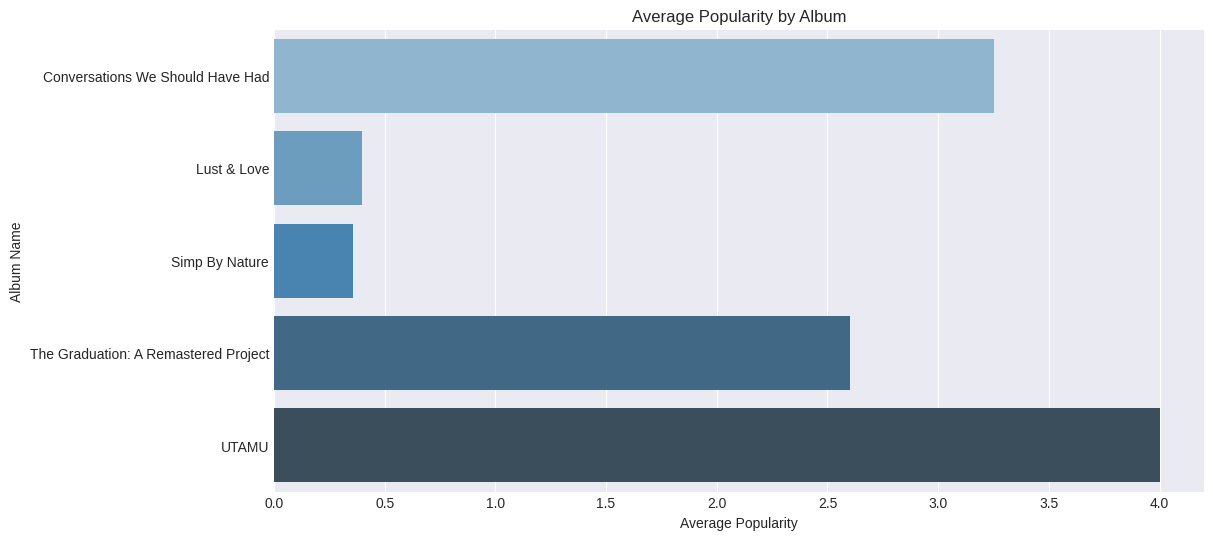

<ipython-input-7-c0db2f55228c>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Danceability', y='Album Name', data=album_performance, palette='Greens_d')


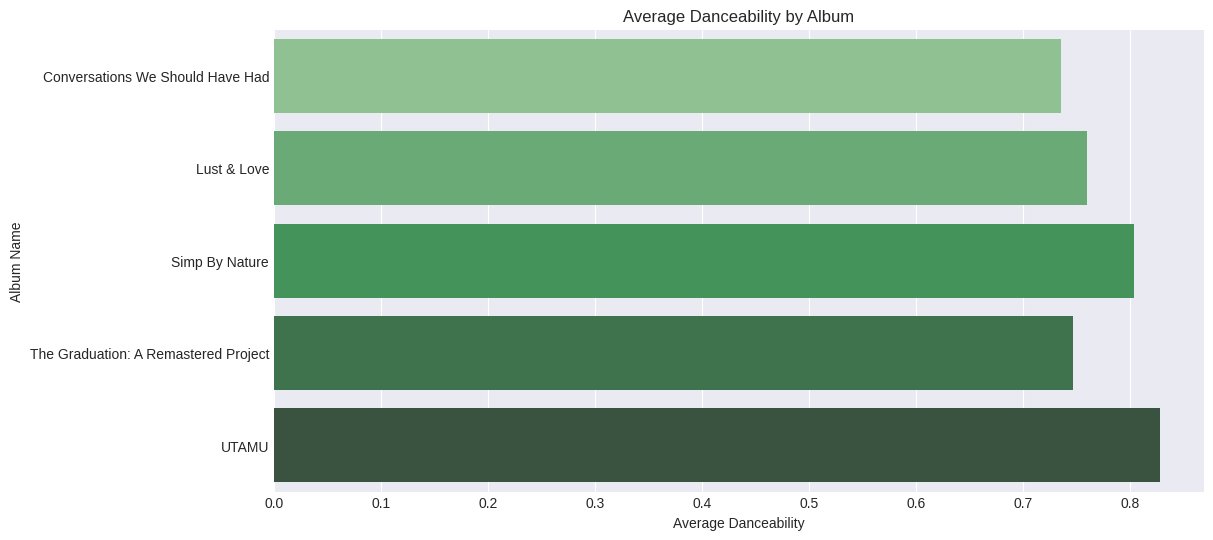

<ipython-input-7-c0db2f55228c>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Energy', y='Album Name', data=album_performance, palette='Reds_d')


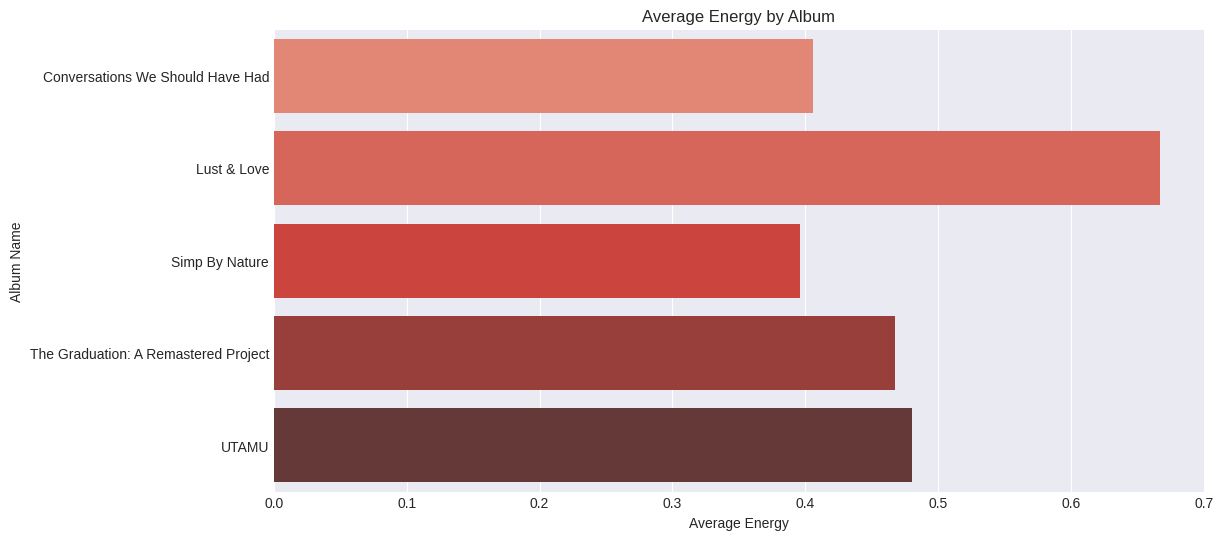

<ipython-input-7-c0db2f55228c>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loudness', y='Album Name', data=album_performance, palette='Purples_d')


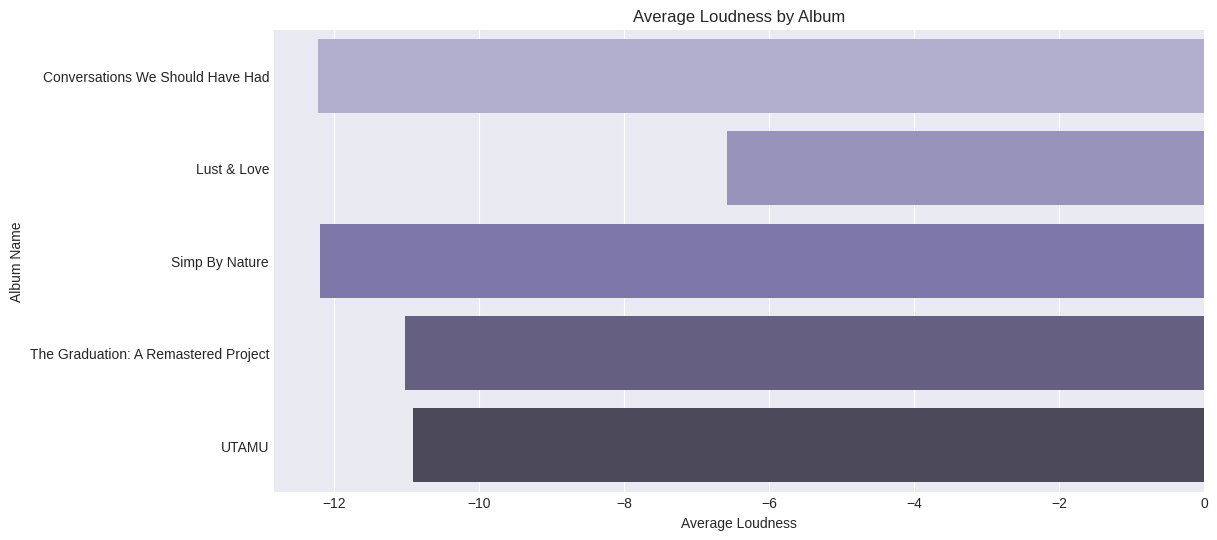

<ipython-input-7-c0db2f55228c>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Track Count', y='Album Name', data=album_performance, palette='Oranges_d')


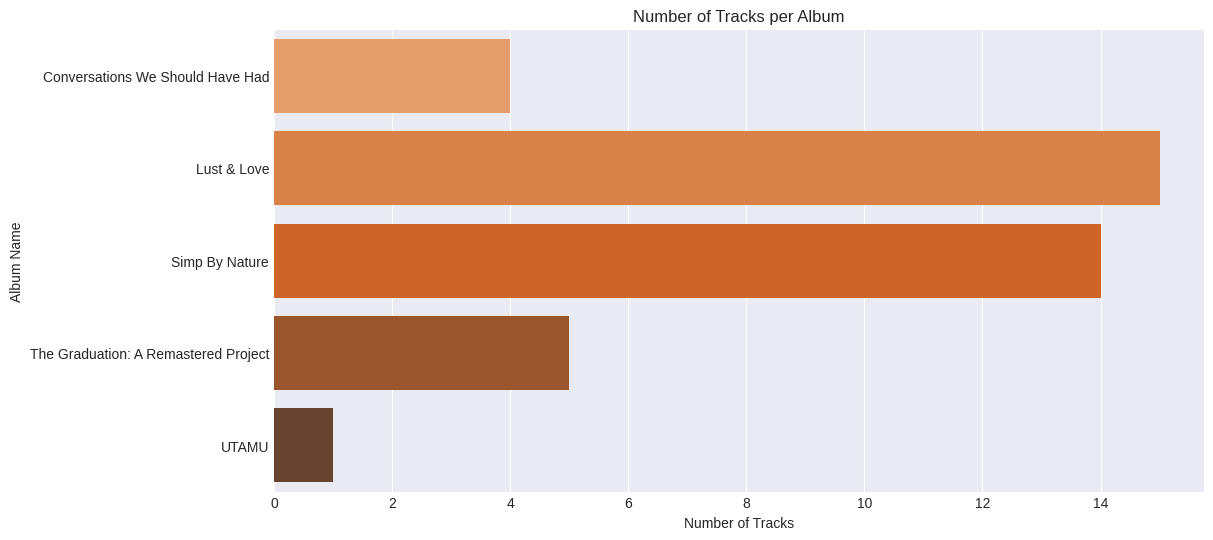

<ipython-input-7-c0db2f55228c>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Unique Artists', y='Album Name', data=album_performance, palette='Blues_d')


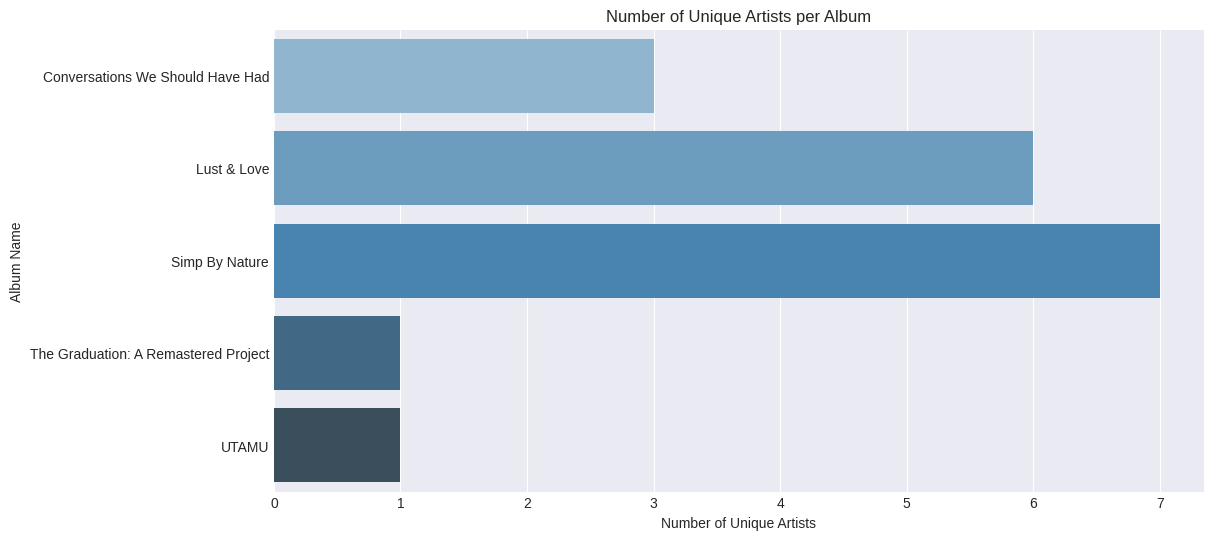

<ipython-input-7-c0db2f55228c>:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Valence', y='Album Name', data=album_performance, palette='pink')


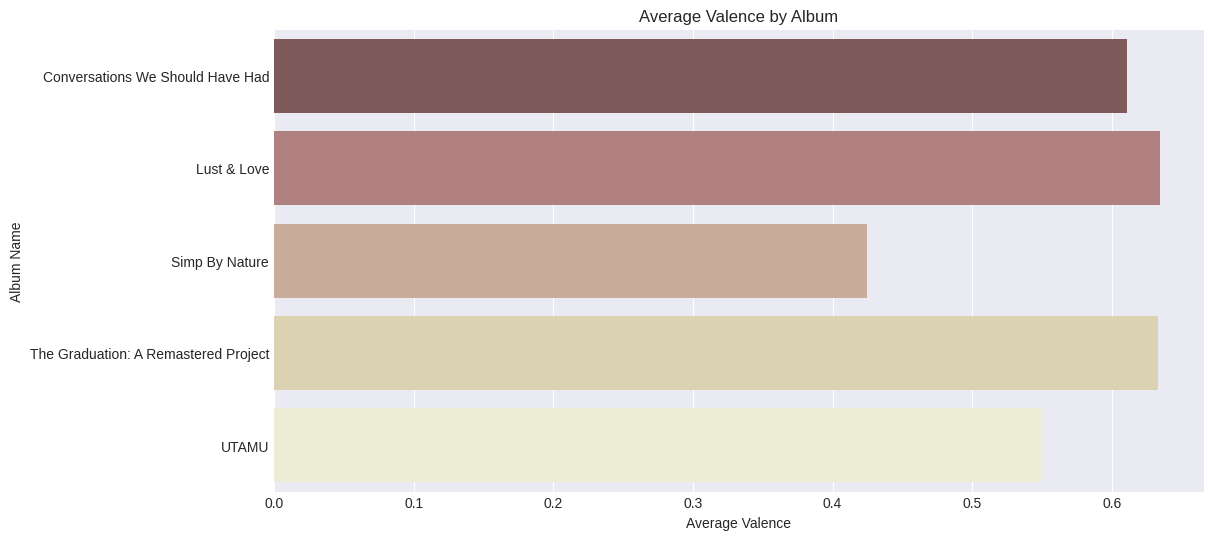

<ipython-input-7-c0db2f55228c>:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tempo', y='Album Name', data=album_performance, palette='Greens_d')


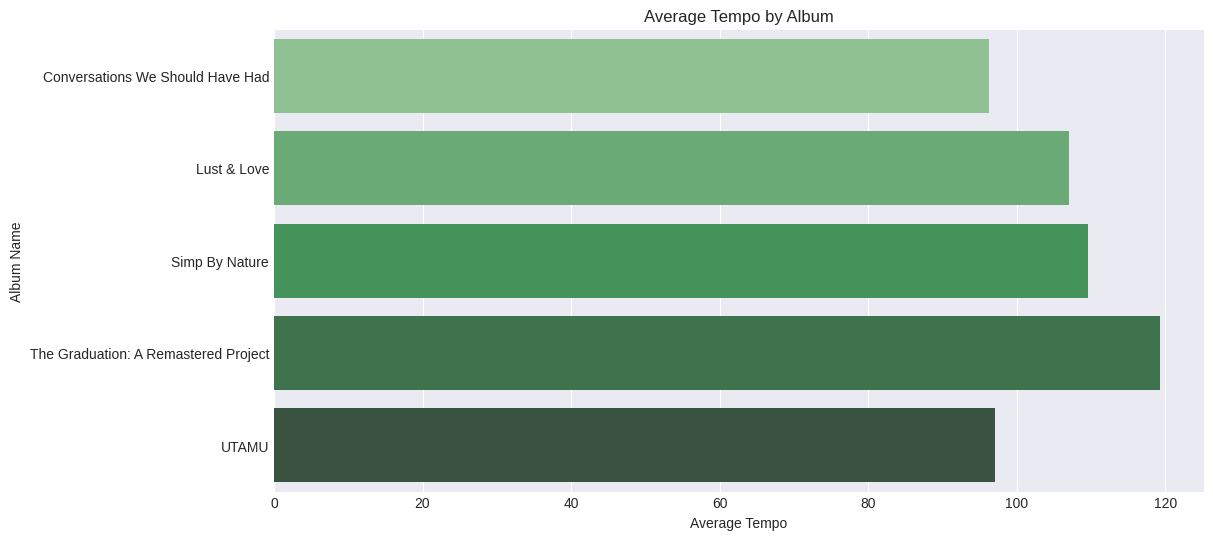

<ipython-input-7-c0db2f55228c>:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Acousticness', y='Album Name', data=album_performance, palette='Blues_d')


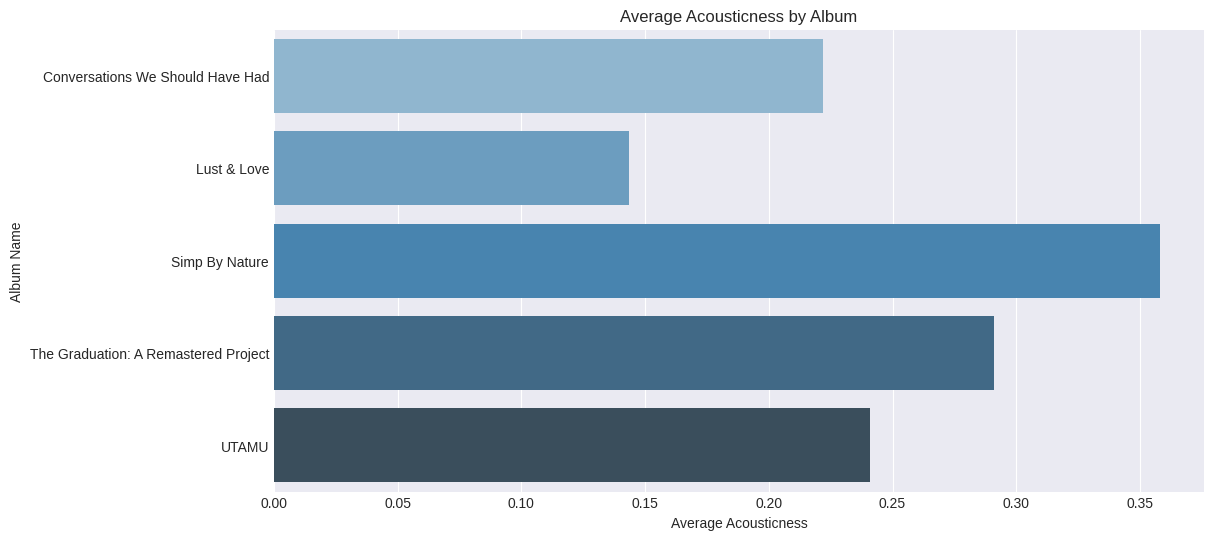

<ipython-input-7-c0db2f55228c>:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Instrumentalness', y='Album Name', data=album_performance, palette='Reds_d')


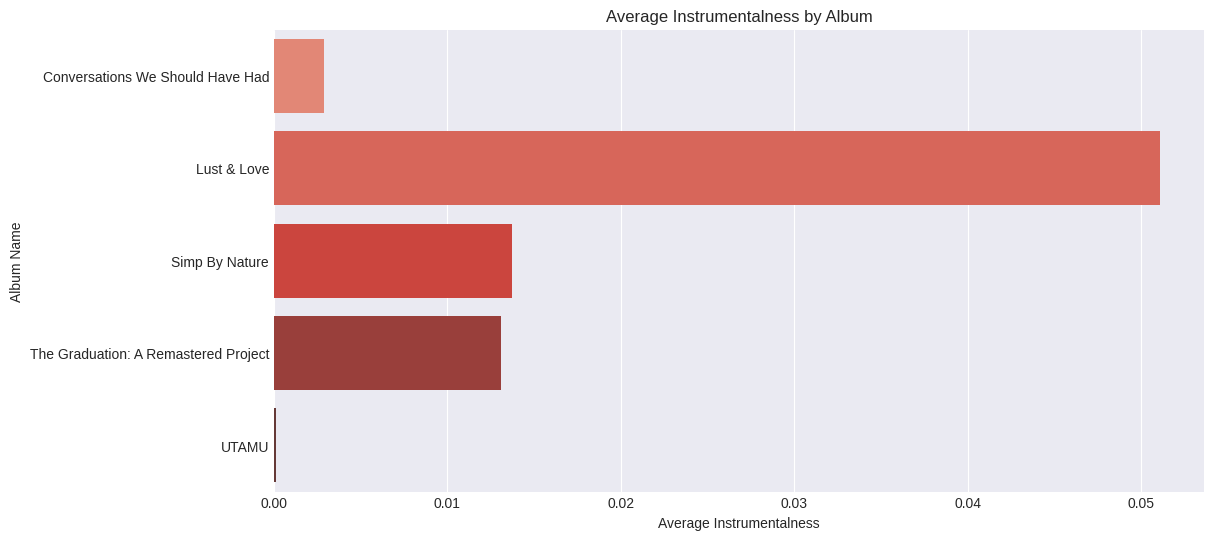

<ipython-input-7-c0db2f55228c>:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Liveness', y='Album Name', data=album_performance, palette='Purples_d')


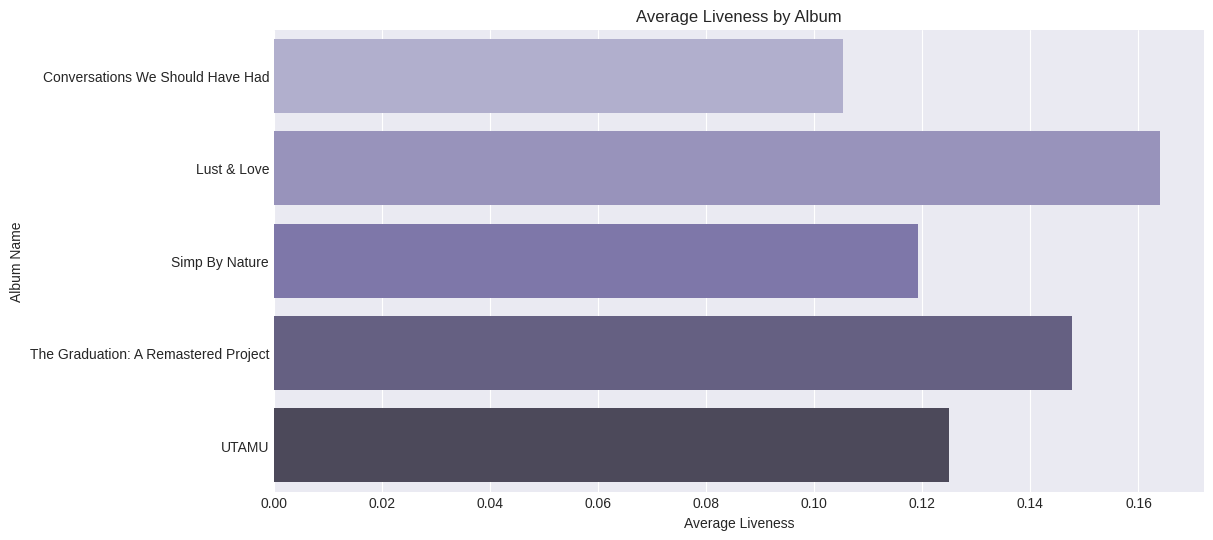

<ipython-input-7-c0db2f55228c>:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Speechiness', y='Album Name', data=album_performance, palette='Oranges_d')


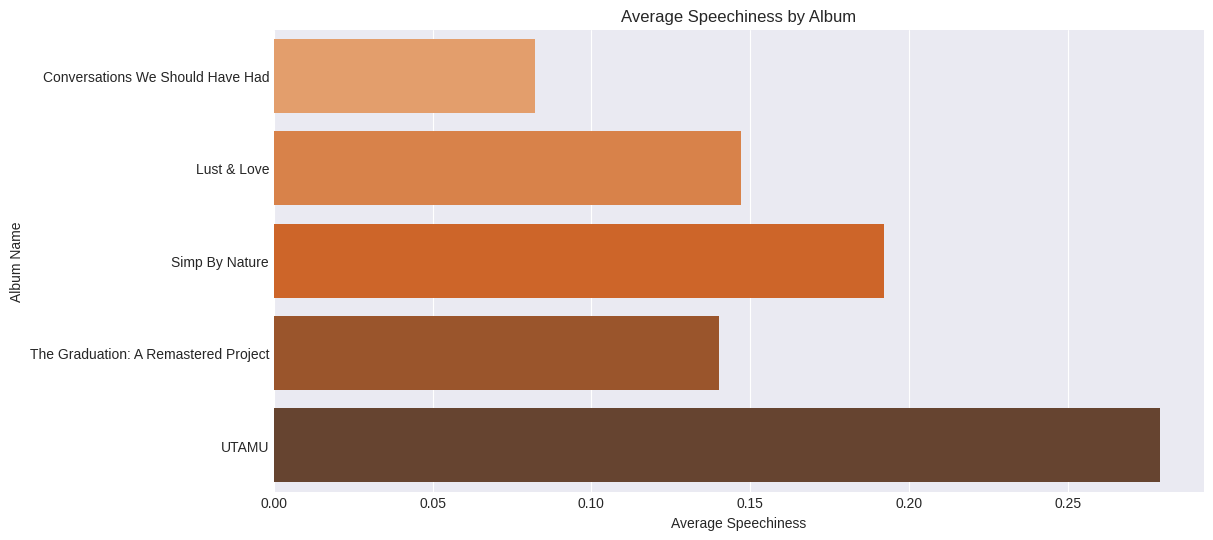

In [7]:
# Numeric columns to be aggregated using mean
numeric_columns = ['Popularity', 'Danceability', 'Energy', 'Loudness', 'Tempo', 'Valence', 'Speechiness',
                   'Acousticness', 'Instrumentalness', 'Liveness', 'Duration (ms)']

# Group by 'Album Name' and compute the mean for numeric columns
album_performance = music_df.groupby('Album Name')[numeric_columns].mean().reset_index()

# Non-numeric columns: Count number of unique tracks and artists per album
album_track_count = music_df.groupby('Album Name')['Track Name'].count().reset_index(name='Track Count')
album_artist_count = music_df.groupby('Album Name')['Artists'].nunique().reset_index(name='Unique Artists')

# Merge track count and artist count with the numeric performance DataFrame
album_performance = pd.merge(album_performance, album_track_count, on='Album Name')
album_performance = pd.merge(album_performance, album_artist_count, on='Album Name')

# Plotting setup
plt.style.use('seaborn-darkgrid')

# 1. Popularity by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Popularity', y='Album Name', data=album_performance, palette='Blues_d')
plt.title('Average Popularity by Album')
plt.xlabel('Average Popularity')
plt.ylabel('Album Name')
plt.show()

# 2. Danceability by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Danceability', y='Album Name', data=album_performance, palette='Greens_d')
plt.title('Average Danceability by Album')
plt.xlabel('Average Danceability')
plt.ylabel('Album Name')
plt.show()

# 3. Energy by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Energy', y='Album Name', data=album_performance, palette='Reds_d')
plt.title('Average Energy by Album')
plt.xlabel('Average Energy')
plt.ylabel('Album Name')
plt.show()

# 4. Loudness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Loudness', y='Album Name', data=album_performance, palette='Purples_d')
plt.title('Average Loudness by Album')
plt.xlabel('Average Loudness')
plt.ylabel('Album Name')
plt.show()

# 5. Number of Tracks per Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Track Count', y='Album Name', data=album_performance, palette='Oranges_d')
plt.title('Number of Tracks per Album')
plt.xlabel('Number of Tracks')
plt.ylabel('Album Name')
plt.show()

# 6. Number of Unique Artists per Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Unique Artists', y='Album Name', data=album_performance, palette='Blues_d')
plt.title('Number of Unique Artists per Album')
plt.xlabel('Number of Unique Artists')
plt.ylabel('Album Name')
plt.show()

# 7. Valence by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Valence', y='Album Name', data=album_performance, palette='pink')
plt.title('Average Valence by Album')
plt.xlabel('Average Valence')
plt.ylabel('Album Name')
plt.show()

# 8. Tempo by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Tempo', y='Album Name', data=album_performance, palette='Greens_d')
plt.title('Average Tempo by Album')
plt.xlabel('Average Tempo')
plt.ylabel('Album Name')
plt.show()

# 9. Acousticness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Acousticness', y='Album Name', data=album_performance, palette='Blues_d')
plt.title('Average Acousticness by Album')
plt.xlabel('Average Acousticness')
plt.ylabel('Album Name')
plt.show()

# 10. Instrumentalness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Instrumentalness', y='Album Name', data=album_performance, palette='Reds_d')
plt.title('Average Instrumentalness by Album')
plt.xlabel('Average Instrumentalness')
plt.ylabel('Album Name')
plt.show()

# 11. Liveness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Liveness', y='Album Name', data=album_performance, palette='Purples_d')
plt.title('Average Liveness by Album')
plt.xlabel('Average Liveness')
plt.ylabel('Album Name')
plt.show()

# 12. Speechiness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Speechiness', y='Album Name', data=album_performance, palette='Oranges_d')
plt.title('Average Speechiness by Album')
plt.xlabel('Average Speechiness')
plt.ylabel('Album Name')
plt.show()
